# Boston 住宅価格予測モデルの探索と視覚化

このノートブックでは、Boston 住宅データを探索し、価格予測モデルの性能を視覚的に分析します。

## 目的

- データの傾向を視覚的に把握する
- 特徴量エンジニアリングの効果を確認する
- モデルの予測精度を可視化する

## 1. 環境セットアップとデータ読み込み

In [14]:
# ライブラリのインポート
import os
import sys

# カレントディレクトリの確認
current_dir = os.getcwd()
print(f"カレントディレクトリ: {current_dir}")

# 親ディレクトリを sys.path に追加（重複チェック）
parent_dir = os.path.abspath("..")
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
    print(f"sys.path に追加: {parent_dir}")
else:
    print(f"既に sys.path に存在: {parent_dir}")

# ディレクトリ構造の確認
print(
    f"\nsrc ディレクトリの存在確認: {os.path.exists(os.path.join(parent_dir, 'src'))}"
)
print(
    f"data ディレクトリの存在確認: {os.path.exists(os.path.join(parent_dir, 'data'))}"
)
print(
    f"src/ml ディレクトリの存在確認: {os.path.exists(os.path.join(parent_dir, 'src', 'ml'))}"
)
print(
    f"boston_predictor.py の存在確認: {os.path.exists(os.path.join(parent_dir, 'src', 'ml', 'boston_predictor.py'))}"
)
print(
    f"src/__init__.py の存在確認: {os.path.exists(os.path.join(parent_dir, 'src', '__init__.py'))}"
)
print(
    f"src/ml/__init__.py の存在確認: {os.path.exists(os.path.join(parent_dir, 'src', 'ml', '__init__.py'))}"
)

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# matplotlibrc ファイルを読み込み（日本語フォント設定）
matplotlibrc_path = os.path.join(parent_dir, "matplotlibrc")
if os.path.exists(matplotlibrc_path):
    matplotlib.rc_file(matplotlibrc_path)
    print(f"\nmatplotlibrc を読み込みました: {matplotlibrc_path}")
else:
    print(f"\nmatplotlibrc が見つかりません: {matplotlibrc_path}")

# スタイル設定
sns.set_style("whitegrid")
sns.set_palette("Set2")

# seaborn 設定後に再度フォント設定を適用（seaborn が設定を上書きするため）
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = [
    "BIZ UDGothic",
    "MS Gothic",
    "Yu Gothic",
    "Meiryo",
    "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False

# フォント設定の確認
print(f"現在のフォント設定: {plt.rcParams['font.sans-serif']}")

print("\n✓ 環境セットアップ完了")

# BostonPredictor のインポート（このセル内で実行）
print("\n--- BostonPredictor のインポート ---")
try:
    from src.ml.boston_predictor import BostonPredictor

    print("✓ BostonPredictor のインポートに成功しました")
except ImportError as e:
    print(f"❌ インポートエラー: {e}")
    print("\n【デバッグ情報】")
    print(f"sys.path の最初の3つ: {sys.path[:3]}")

    # 代替インポート方法を試す
    print("\n代替インポート方法を試します...")
    import importlib.util

    spec = importlib.util.spec_from_file_location(
        "boston_predictor", os.path.join(parent_dir, "src", "ml", "boston_predictor.py")
    )
    boston_module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(boston_module)
    BostonPredictor = boston_module.BostonPredictor
    print("✓ 代替方法でインポートに成功しました")

print("\n✓ すべての準備が完了しました")

カレントディレクトリ: C:\Users\PC202411-1\IdeaProjects\case-study-game-dev\app\python\ml_tdd\notebook
既に sys.path に存在: C:\Users\PC202411-1\IdeaProjects\case-study-game-dev\app\python\ml_tdd

src ディレクトリの存在確認: True
data ディレクトリの存在確認: True
src/ml ディレクトリの存在確認: True
boston_predictor.py の存在確認: True
src/__init__.py の存在確認: True
src/ml/__init__.py の存在確認: True

matplotlibrc が見つかりません: C:\Users\PC202411-1\IdeaProjects\case-study-game-dev\app\python\ml_tdd\matplotlibrc
現在のフォント設定: ['BIZ UDGothic', 'MS Gothic', 'Yu Gothic', 'Meiryo', 'DejaVu Sans']

✓ 環境セットアップ完了

--- BostonPredictor のインポート ---
✓ BostonPredictor のインポートに成功しました

✓ すべての準備が完了しました


In [15]:
# データの読み込み
predictor = BostonPredictor()
df = predictor.load_data("../data/Boston.csv")

print("✓ データ読み込み完了")
print(f"データ形状: {df.shape}")
print(f"\n列: {df.columns.tolist()}")
print("\n基本統計量:")
print(df[["RM", "LSTAT", "PTRATIO", "PRICE"]].describe())
print("\n欠損値の数:")
print(df.isnull().sum())

✓ データ読み込み完了
データ形状: (100, 14)

列: ['CRIME', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'PRICE']

基本統計量:
               RM       LSTAT    PTRATIO       PRICE
count  100.000000  100.000000  100.00000  100.000000
mean     6.235930   11.826400   18.51700   23.457000
std      0.768287    6.830843    1.94251    9.570211
min      3.561000    1.920000   13.00000    5.000000
25%      5.870500    6.772500   17.60000   17.800000
50%      6.135500   10.445000   18.65000   21.500000
75%      6.457250   14.482500   20.20000   24.800000
max      8.704000   30.590000   22.00000   50.000000

欠損値の数:
CRIME      0
ZN         0
INDUS      0
CHAS       0
NOX        1
RM         0
AGE        0
DIS        0
RAD        1
TAX        0
PTRATIO    0
B          0
LSTAT      0
PRICE      0
dtype: int64


## 2. データの探索と可視化

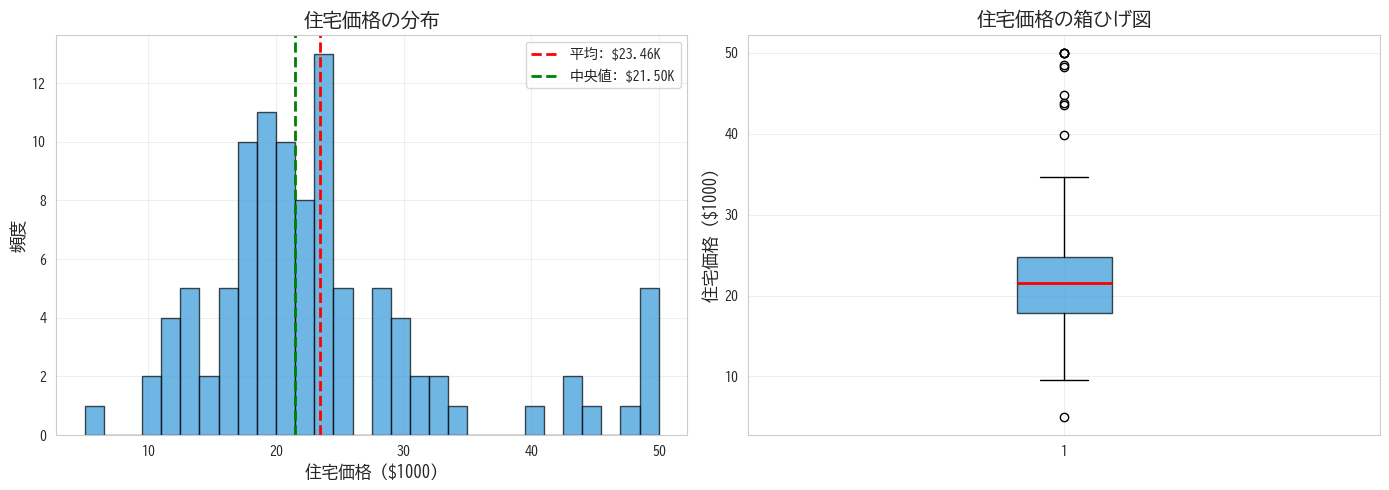


価格統計:
  平均: $23.46K
  中央値: $21.50K
  最小値: $5.00K
  最大値: $50.00K


In [16]:
# 目的変数（PRICE）の分布
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ヒストグラム
ax1.hist(df["PRICE"], bins=30, color="#3498db", edgecolor="black", alpha=0.7)
ax1.set_xlabel("住宅価格 ($1000)", fontsize=12)
ax1.set_ylabel("頻度", fontsize=12)
ax1.set_title("住宅価格の分布", fontsize=14)
ax1.axvline(
    df["PRICE"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"平均: ${df['PRICE'].mean():.2f}K",
)
ax1.axvline(
    df["PRICE"].median(),
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"中央値: ${df['PRICE'].median():.2f}K",
)
ax1.legend()
ax1.grid(True, alpha=0.3)

# 箱ひげ図
ax2.boxplot(
    df["PRICE"],
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor="#3498db", alpha=0.7),
    medianprops=dict(color="red", linewidth=2),
)
ax2.set_ylabel("住宅価格 ($1000)", fontsize=12)
ax2.set_title("住宅価格の箱ひげ図", fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n価格統計:")
print(f"  平均: ${df['PRICE'].mean():.2f}K")
print(f"  中央値: ${df['PRICE'].median():.2f}K")
print(f"  最小値: ${df['PRICE'].min():.2f}K")
print(f"  最大値: ${df['PRICE'].max():.2f}K")

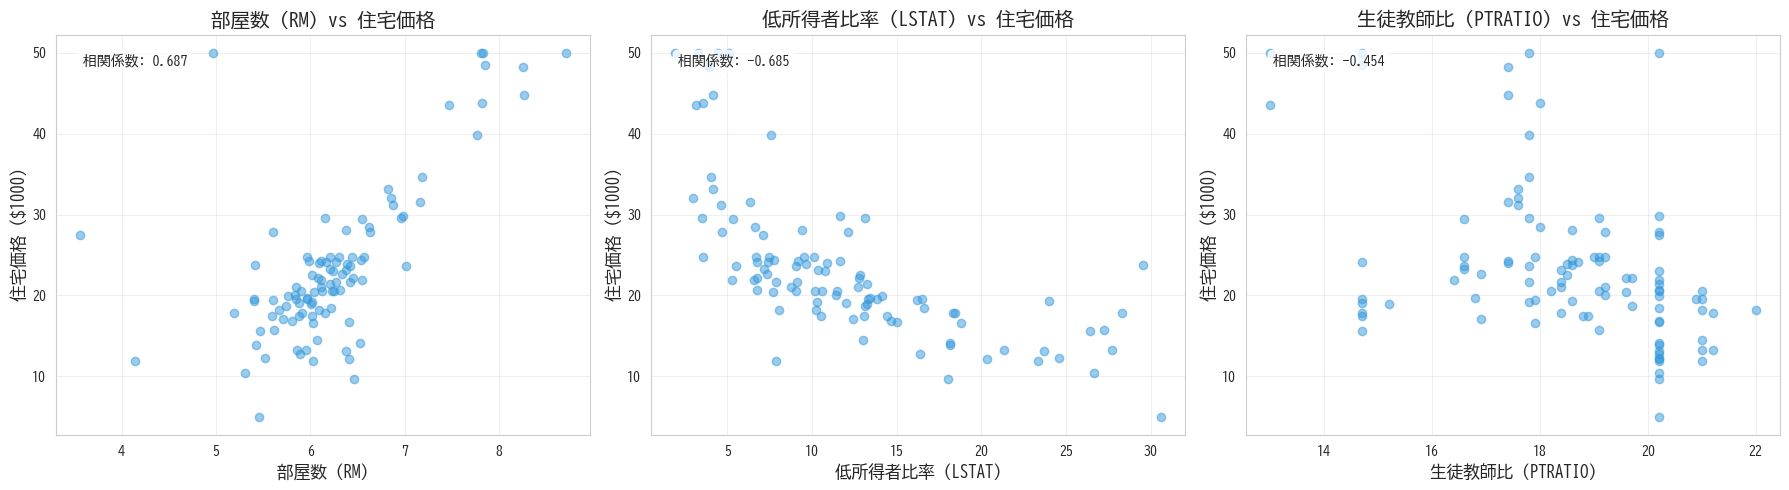

In [17]:
# 特徴量と目的変数の相関
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

features = ["RM", "LSTAT", "PTRATIO"]
feature_names = ["部屋数 (RM)", "低所得者比率 (LSTAT)", "生徒教師比 (PTRATIO)"]

for i, (feature, name) in enumerate(zip(features, feature_names)):
    axes[i].scatter(df[feature], df["PRICE"], alpha=0.5, color="#3498db")
    axes[i].set_xlabel(name, fontsize=12)
    axes[i].set_ylabel("住宅価格 ($1000)", fontsize=12)
    axes[i].set_title(f"{name} vs 住宅価格", fontsize=14)
    axes[i].grid(True, alpha=0.3)

    # 相関係数を計算して表示
    corr = df[feature].corr(df["PRICE"])
    axes[i].text(
        0.05,
        0.95,
        f"相関係数: {corr:.3f}",
        transform=axes[i].transAxes,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
        verticalalignment="top",
    )

plt.tight_layout()
plt.show()

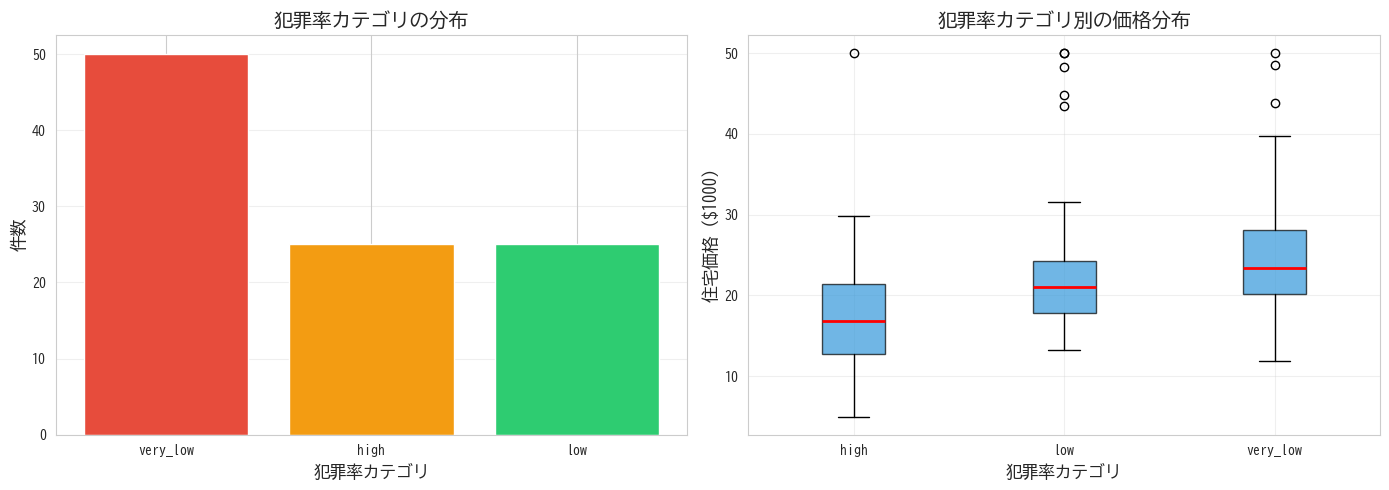


犯罪率カテゴリ別の平均価格:
  high: $18.46K
  low: $25.48K
  very_low: $24.95K


In [18]:
# CRIME カテゴリの分布
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# カウントプロット
crime_counts = df["CRIME"].value_counts()
ax1.bar(
    crime_counts.index, crime_counts.values, color=["#e74c3c", "#f39c12", "#2ecc71"]
)
ax1.set_xlabel("犯罪率カテゴリ", fontsize=12)
ax1.set_ylabel("件数", fontsize=12)
ax1.set_title("犯罪率カテゴリの分布", fontsize=14)
ax1.grid(True, alpha=0.3, axis="y")

# カテゴリ別の価格分布
crime_categories = df["CRIME"].unique()
crime_prices = [df[df["CRIME"] == cat]["PRICE"].values for cat in crime_categories]
ax2.boxplot(
    crime_prices,
    tick_labels=crime_categories,
    patch_artist=True,
    boxprops=dict(facecolor="#3498db", alpha=0.7),
    medianprops=dict(color="red", linewidth=2),
)
ax2.set_xlabel("犯罪率カテゴリ", fontsize=12)
ax2.set_ylabel("住宅価格 ($1000)", fontsize=12)
ax2.set_title("犯罪率カテゴリ別の価格分布", fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n犯罪率カテゴリ別の平均価格:")
for cat in crime_categories:
    avg_price = df[df["CRIME"] == cat]["PRICE"].mean()
    print(f"  {cat}: ${avg_price:.2f}K")

## 3. 前処理とモデル訓練

In [19]:
# データの前処理
df_processed = predictor._encode_crime(df)
df_processed = predictor._fill_missing_values(df_processed, fit=True)
df_processed = predictor._remove_outliers(df_processed)

print(f"前処理後のデータ形状: {df_processed.shape}")
print(f"除外されたサンプル数: {len(df) - len(df_processed)}")

# 特徴量と目的変数の分離
feature_columns = ["RM", "LSTAT", "PTRATIO"]
X = df_processed[feature_columns]
y = df_processed[["PRICE"]]

# 訓練データとテストデータに分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

print(f"\n訓練データ: {len(X_train)} サンプル")
print(f"テストデータ: {len(X_test)} サンプル")

前処理後のデータ形状: (99, 15)
除外されたサンプル数: 1

訓練データ: 79 サンプル
テストデータ: 20 サンプル


In [20]:
# 特徴量エンジニアリング
X_train_eng = predictor.feature_engineering(X_train)
X_test_eng = predictor.feature_engineering(X_test)

print(f"特徴量エンジニアリング後の特徴量数: {X_train_eng.shape[1]}")
print(f"特徴量: {X_train_eng.columns.tolist()}")

# 標準化
X_train_scaled = predictor.standardize_features(X_train_eng, fit=True)
X_test_scaled = predictor.standardize_features(X_test_eng, fit=False)
y_train_scaled = predictor.standardize_target(y_train, fit=True)
y_test_scaled = predictor.standardize_target(y_test, fit=False)

print("\n標準化完了")

特徴量エンジニアリング後の特徴量数: 7
特徴量: ['RM', 'LSTAT', 'PTRATIO', 'RM2', 'LSTAT2', 'PTRATIO2', 'RM * LSTAT']

標準化完了


In [21]:
# モデルの訓練
predictor.train(X_train_scaled, y_train_scaled)
print("モデルの訓練が完了しました")

# モデルの評価
score = predictor.evaluate(X_test_scaled, y_test_scaled)
print(f"\n決定係数（R^2）: {score:.4f}")

# モデルの係数を表示
print("\nモデルの係数:")
feature_names = X_train_eng.columns.tolist()
coefficients = predictor.model.coef_
for name, coef in zip(feature_names, coefficients):
    print(f"  {name}: {coef:.4f}")
print(f"  切片: {predictor.model.intercept_:.4f}")

モデルの訓練が完了しました

決定係数（R^2）: 0.8544

モデルの係数:
  RM: -2.0241
  LSTAT: 0.1606
  PTRATIO: 1.4309
  RM2: 2.6621
  LSTAT2: 0.2150
  PTRATIO2: -1.5610
  RM * LSTAT: -0.6230
  切片: -0.0000


## 4. 予測結果の可視化

In [22]:
# 予測
y_pred_scaled = predictor.predict(X_test_scaled)
y_pred = predictor.inverse_transform_prediction(y_pred_scaled.reshape(-1, 1))

# 評価指標の計算
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("評価指標:")
print(f"  MSE (平均二乗誤差): {mse:.4f}")
print(f"  RMSE (二乗平均平方根誤差): {rmse:.4f}")
print(f"  MAE (平均絶対誤差): {mae:.4f}")
print(f"  R^2 (決定係数): {r2:.4f}")

評価指標:
  MSE (平均二乗誤差): 11.8808
  RMSE (二乗平均平方根誤差): 3.4468
  MAE (平均絶対誤差): 2.5099
  R^2 (決定係数): 0.8544


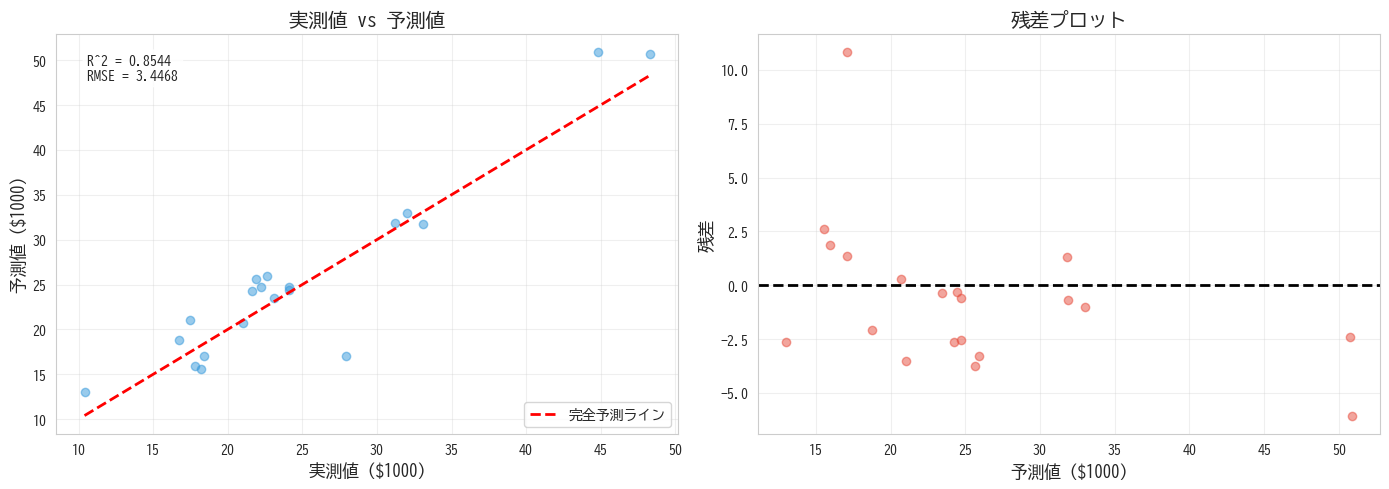

In [23]:
# 実測値 vs 予測値のプロット
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 散布図
ax1.scatter(y_test, y_pred, alpha=0.5, color="#3498db")
ax1.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2,
    label="完全予測ライン",
)
ax1.set_xlabel("実測値 ($1000)", fontsize=12)
ax1.set_ylabel("予測値 ($1000)", fontsize=12)
ax1.set_title("実測値 vs 予測値", fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# R^2 スコアを表示
ax1.text(
    0.05,
    0.95,
    f"R^2 = {r2:.4f}\nRMSE = {rmse:.4f}",
    transform=ax1.transAxes,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    verticalalignment="top",
)

# 残差プロット
residuals = y_test.values.flatten() - y_pred.flatten()
ax2.scatter(y_pred, residuals, alpha=0.5, color="#e74c3c")
ax2.axhline(y=0, color="black", linestyle="--", linewidth=2)
ax2.set_xlabel("予測値 ($1000)", fontsize=12)
ax2.set_ylabel("残差", fontsize=12)
ax2.set_title("残差プロット", fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

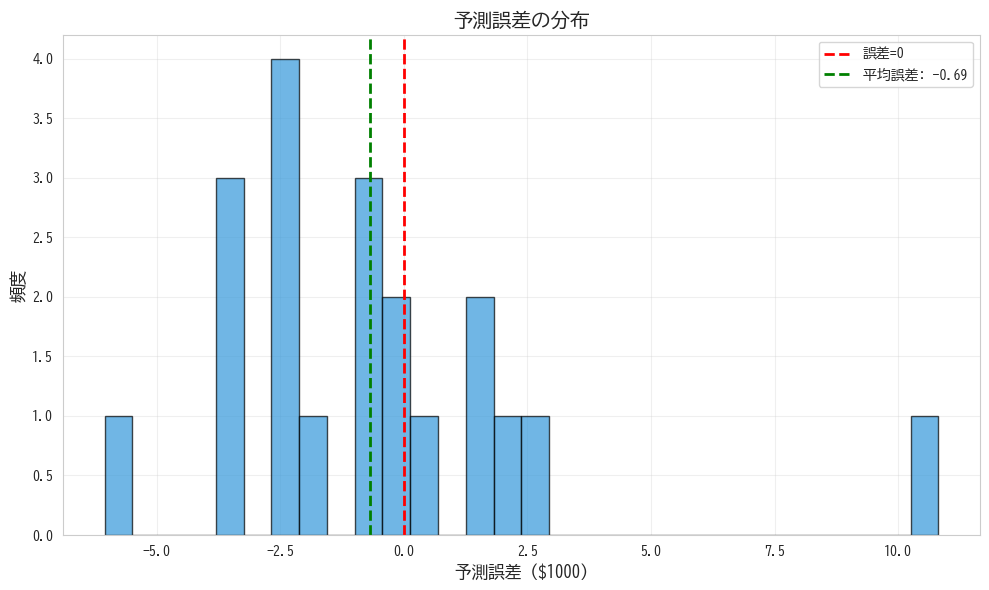


誤差統計:
  平均誤差: $-0.6855K
  誤差の標準偏差: $3.3780K
  最大過大評価: $-6.0546K
  最大過小評価: $10.8097K


In [24]:
# 予測誤差の分布
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(residuals, bins=30, color="#3498db", edgecolor="black", alpha=0.7)
ax.axvline(0, color="red", linestyle="--", linewidth=2, label="誤差=0")
ax.axvline(
    residuals.mean(),
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"平均誤差: {residuals.mean():.2f}",
)
ax.set_xlabel("予測誤差 ($1000)", fontsize=12)
ax.set_ylabel("頻度", fontsize=12)
ax.set_title("予測誤差の分布", fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n誤差統計:")
print(f"  平均誤差: ${residuals.mean():.4f}K")
print(f"  誤差の標準偏差: ${residuals.std():.4f}K")
print(f"  最大過大評価: ${residuals.min():.4f}K")
print(f"  最大過小評価: ${residuals.max():.4f}K")

## 5. まとめ

このノートブックでは、以下の内容を確認しました：

1. **データの探索**
   - 住宅価格の分布
   - 特徴量と目的変数の相関
   - 犯罪率カテゴリの影響

2. **特徴量エンジニアリング**
   - 2乗項の追加（RM2, LSTAT2, PTRATIO2）
   - 交互作用項の追加（RM * LSTAT）
   - 特徴量の標準化

3. **モデルの性能**
   - 決定係数（R^2）による評価
   - 実測値 vs 予測値の散布図
   - 残差分析

TDD により実装した BostonPredictor クラスは、住宅価格を高い精度で予測できることが確認できました。